# Flagship vs DP2 Truth: Angular Power Spectra Comparison

Compares galaxy clustering $C_\ell$ from:
- **Flagship** (`flagship_lens`) — new Flagship DP2 mock catalogs
- **DP2 Truth 23.5** (`dp2_23p5_nmin500_truth_combined_mask`) — noise-free simulation magnitudes

Toggle `scale` in the dedicated cell to switch between display modes:
- `'loglog'`  →  $\ell(\ell+1)C_\ell/2\pi$, log–log axes
- `'linear'`  →  $\ell^{1.3}\,C_\ell$, linear axes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sacc


# ── load_cls (from txpipe_util.ipynb) ─────────────────────────────────────────
def load_cls(sacc_file):
    """Load all C_ell measurements grouped by data type and bin pair.

    Returns
    -------
    s       : sacc.Sacc
    results : dict  { data_type: [(t1, t2, ell, cl, err), ...] }
    """
    s = sacc.Sacc.load_fits(sacc_file)
    data_types = set(dp.data_type for dp in s.data)
    print(f"Data types found: {sorted(data_types)}")

    results = {}
    for dt in sorted(data_types):
        tracers = s.get_tracer_combinations(dt)
        entries = []
        for (t1, t2) in tracers:
            ell, cl = s.get_ell_cl(dt, t1, t2)
            try:
                indices = s.indices(dt, (t1, t2))
                cov = s.covariance.dense[np.ix_(indices, indices)]
                err = np.sqrt(np.diag(cov))
            except Exception:
                err = np.zeros_like(cl)
            entries.append((t1, t2, ell, cl, err))
        results[dt] = entries

    return s, results


def parse_bin_index(tracer_name):
    """Extract integer bin index from a tracer name like 'lens_2'."""
    parts = tracer_name.rsplit("_", 1)
    try:
        return int(parts[-1])
    except ValueError:
        return 0


def bin_label(tracer_name):
    """Turn 'lens_0' into 'Lens 0' etc."""
    parts = tracer_name.rsplit("_", 1)
    if len(parts) == 2:
        return f"{parts[0].capitalize()} {parts[1]}"
    return tracer_name

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
BASE = "data/outputs"

sacc_flagship = f"{BASE}/flagship_lens/summary_statistics_fourier.sacc"
sacc_truth    = f"{BASE}/dp2_23p5_nmin500_truth_combined_mask/summary_statistics_fourier.sacc"

output_dir = None   # set to a directory path string to save PNGs

In [3]:
# ── load both SACC files ──────────────────────────────────────────────────────
print("Loading Flagship Cls...")
s_flagship, res_flagship = load_cls(sacc_flagship)

print("\nLoading DP2 Truth 23.5 Cls...")
s_truth, res_truth = load_cls(sacc_truth)

Loading Flagship Cls...
Data types found: ['galaxy_density_cl']

Loading DP2 Truth 23.5 Cls...
Data types found: ['galaxy_density_cl']


In [4]:
def compare_cls_overlay(
    res_a,
    res_b,
    label_a,
    label_b,
    data_type="galaxy_density_cl",
    scale="loglog",
    output_path=None,
):
    """Overlay two sets of C_ell on a lower-triangular bin-pair grid.

    Parameters
    ----------
    res_a, res_b : dict
        Output of load_cls (the results dict).
    label_a, label_b : str
        Legend labels for each run.
    data_type : str
        SACC data type key (e.g. 'galaxy_density_cl').
    scale : {'loglog', 'linear'}
        'loglog'  ->  ell*(ell+1)/(2*pi) factor, log-log axes.
        'linear'  ->  ell**1.3 factor, fully linear axes.
    output_path : str or None
        If given, save figure there; otherwise show interactively.
    """
    entries_a = res_a.get(data_type, [])
    entries_b = res_b.get(data_type, [])
    if not entries_a or not entries_b:
        print(f"No data for type '{data_type}'")
        return

    all_tracers = sorted(
        set(t for t1, t2, *_ in entries_a for t in (t1, t2)),
        key=lambda t: (t.rsplit("_", 1)[0], parse_bin_index(t)),
    )
    nbin = len(all_tracers)
    tidx = {t: i for i, t in enumerate(all_tracers)}

    lut_a = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_a}
    lut_b = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_b}

    if scale == "loglog":
        ylabel = r"$\ell(\ell+1)C_\ell/2\pi$"
        title_scale = r"$\ell(\ell+1)C_\ell^{gg}/2\pi$"
    else:
        ylabel = r"$\ell^{1.3}\,C_\ell$"
        title_scale = r"$\ell^{1.3}\,C_\ell^{gg}$"

    fig, axes = plt.subplots(
        nbin, nbin,
        figsize=(4.5 * nbin, 4.0 * nbin),
        squeeze=False,
    )
    fig.suptitle(
        f"{title_scale}  —  {label_a} vs {label_b}",
        fontsize=15, y=1.01,
    )

    for r in range(nbin):
        for c in range(nbin):
            axes[r][c].set_visible(False)

    for t1, t2, *_ in entries_a:
        key = (t1, t2)
        if key not in lut_b:
            print(f"  Pair {key} missing from '{label_b}' — skipping")
            continue

        ell_a, cl_a, err_a = lut_a[key]
        ell_b, cl_b, err_b = lut_b[key]

        i = tidx[t1]
        j = tidx[t2]
        if i < j:
            i, j = j, i

        ax = axes[i][j]
        ax.set_visible(True)

        if scale == "loglog":
            fac_a = ell_a * (ell_a + 1) / (2 * np.pi)
            fac_b = ell_b * (ell_b + 1) / (2 * np.pi)
        else:
            fac_a = ell_a ** 1.3
            fac_b = ell_b ** 1.3

        y_a, ye_a = fac_a * cl_a, fac_a * err_a
        y_b, ye_b = fac_b * cl_b, fac_b * err_b

        # Run A: solid blue circles
        ax.errorbar(
            ell_a, y_a, yerr=ye_a,
            fmt="o", ms=4, lw=1.5, capsize=3, capthick=1.2,
            color="#4363D8", label=label_a, zorder=3,
        )

        # Run B: dashed red squares, nudged 4% in ell
        ax.errorbar(
            ell_b * 1.04, y_b, yerr=ye_b,
            fmt="s", ms=4, lw=1.5, capsize=3, capthick=1.2,
            color="#E6194B", label=label_b, zorder=3,
            linestyle="--",
        )

        if scale == "loglog":
            ax.set_xscale("log")
            ax.set_yscale("log")
        # 'linear': both axes remain linear

        ax.grid(True, which="both", ls=":", alpha=0.35)

        title = (
            f"{bin_label(t1)} (auto)"
            if t1 == t2
            else f"{bin_label(t1)} × {bin_label(t2)}"
        )
        ax.set_title(title, fontsize=10, fontweight="bold" if t1 == t2 else "normal")
        ax.set_xlabel(r"$\ell$", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=8, framealpha=0.8)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()

In [5]:
def compare_cls_ratio(
    res_a,
    res_b,
    label_a,
    label_b,
    data_type="galaxy_density_cl",
    output_path=None,
):
    """Plot the ratio res_a / res_b for each bin pair.

    Error bars are propagated assuming the two runs are independent.
    A ratio consistent with 1 means the two catalogs give consistent clustering.
    """
    entries_a = res_a.get(data_type, [])
    entries_b = res_b.get(data_type, [])
    if not entries_a or not entries_b:
        print(f"No data for type '{data_type}'")
        return

    all_tracers = sorted(
        set(t for t1, t2, *_ in entries_a for t in (t1, t2)),
        key=lambda t: (t.rsplit("_", 1)[0], parse_bin_index(t)),
    )
    nbin = len(all_tracers)
    tidx = {t: i for i, t in enumerate(all_tracers)}

    lut_a = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_a}
    lut_b = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_b}

    fig, axes = plt.subplots(
        nbin, nbin,
        figsize=(4.5 * nbin, 3.5 * nbin),
        squeeze=False,
    )
    fig.suptitle(
        f"$C_\\ell^{{gg}}$ ratio: {label_a} / {label_b}",
        fontsize=15, y=1.01,
    )

    for r in range(nbin):
        for c in range(nbin):
            axes[r][c].set_visible(False)

    for t1, t2, *_ in entries_a:
        key = (t1, t2)
        if key not in lut_b:
            continue

        ell_a, cl_a, err_a = lut_a[key]
        ell_b, cl_b, err_b = lut_b[key]

        i = tidx[t1]
        j = tidx[t2]
        if i < j:
            i, j = j, i

        ax = axes[i][j]
        ax.set_visible(True)

        ratio = np.where(np.abs(cl_b) > 0, cl_a / cl_b, np.nan)
        with np.errstate(invalid="ignore", divide="ignore"):
            frac_err = np.sqrt(
                np.where(cl_a != 0, (err_a / cl_a) ** 2, 0)
                + np.where(cl_b != 0, (err_b / cl_b) ** 2, 0)
            )
        ratio_err = np.abs(ratio) * frac_err

        ax.axhline(1.0, color="grey", lw=1.0, ls="--")
        ax.errorbar(
            ell_a, ratio, yerr=ratio_err,
            fmt="o", ms=4, lw=1.5, capsize=3, capthick=1.2,
            color="#3CB44B",
        )

        ax.set_xscale("log")
        ax.grid(True, which="both", ls=":", alpha=0.35)

        title = (
            f"{bin_label(t1)} (auto)"
            if t1 == t2
            else f"{bin_label(t1)} × {bin_label(t2)}"
        )
        ax.set_title(title, fontsize=10, fontweight="bold" if t1 == t2 else "normal")
        ax.set_xlabel(r"$\ell$", fontsize=10)
        ax.set_ylabel(
            f"$C_\\ell^{{\\rm {label_a.replace(' ', '\\ ')}}} / C_\\ell^{{\\rm {label_b.replace(' ', '\\ ')}}}$",
            fontsize=9,
        )

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()

In [6]:
# ── toggle display style here ─────────────────────────────────────────────────
# 'loglog'  ->  ell*(ell+1)/(2*pi) factor, log-log axes
# 'linear'  ->  ell**1.3 factor, fully linear axes
scale = "linear"

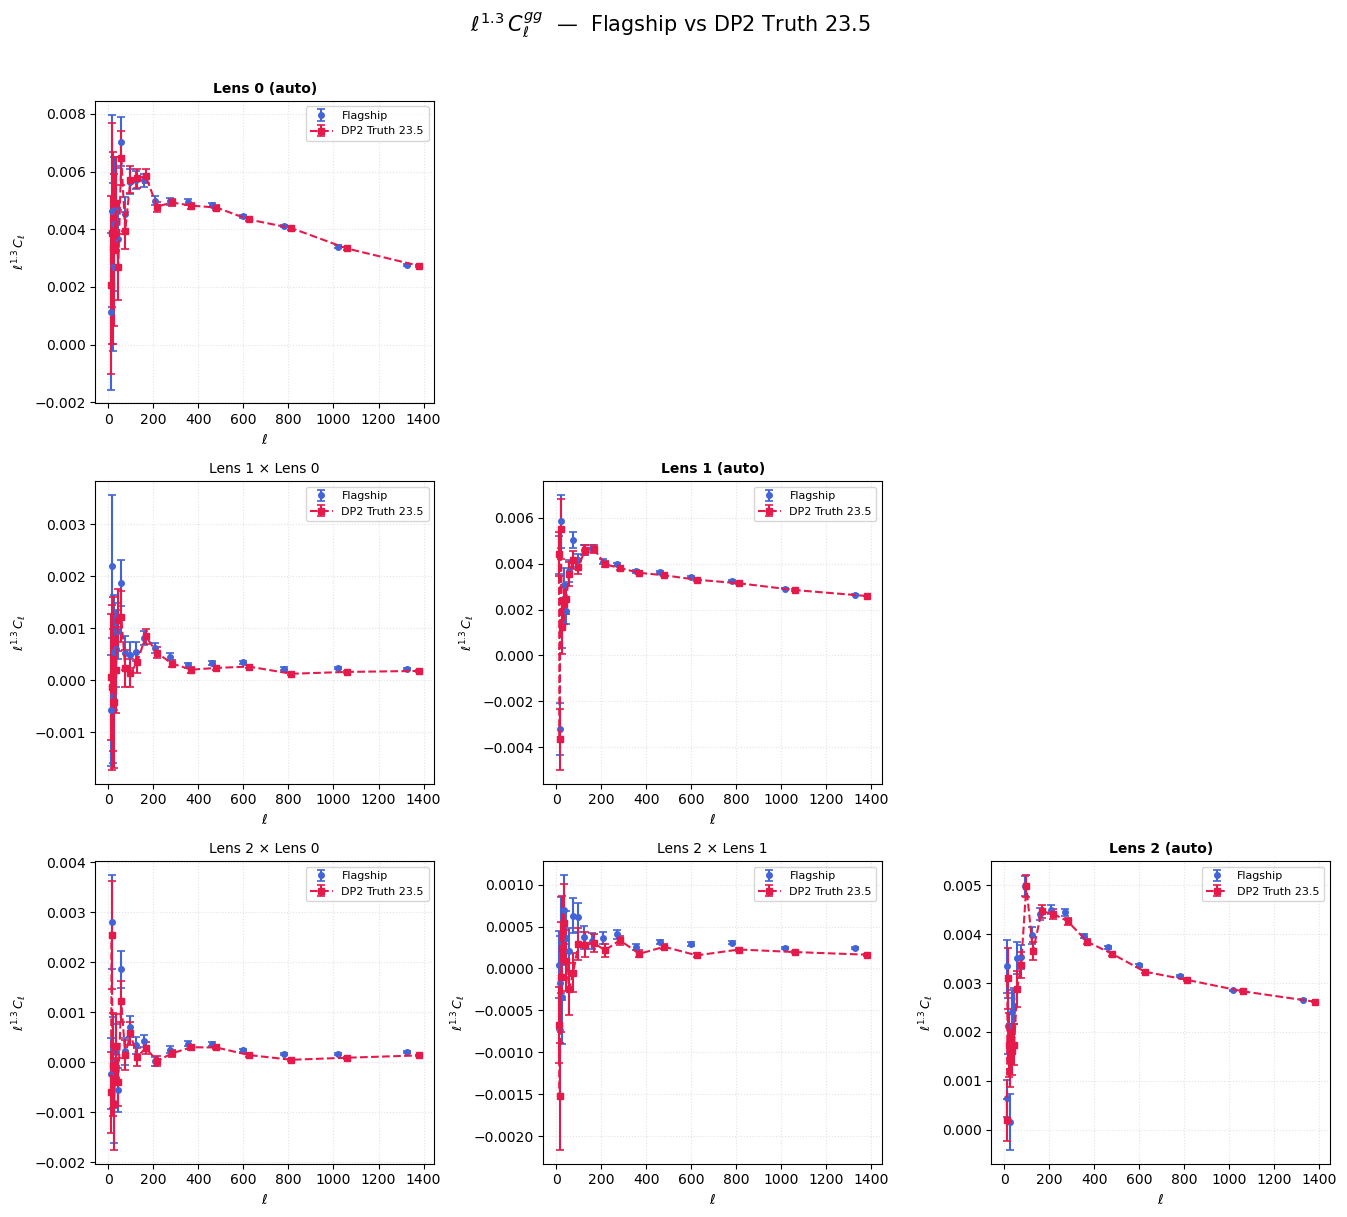

In [7]:
# ── overlay plot ──────────────────────────────────────────────────────────────
out = (
    f"{output_dir}/flagship_vs_truth_overlay_{scale}.png"
    if output_dir else None
)
compare_cls_overlay(
    res_flagship, res_truth,
    "Flagship", "DP2 Truth 23.5",
    scale=scale, output_path=out,
)

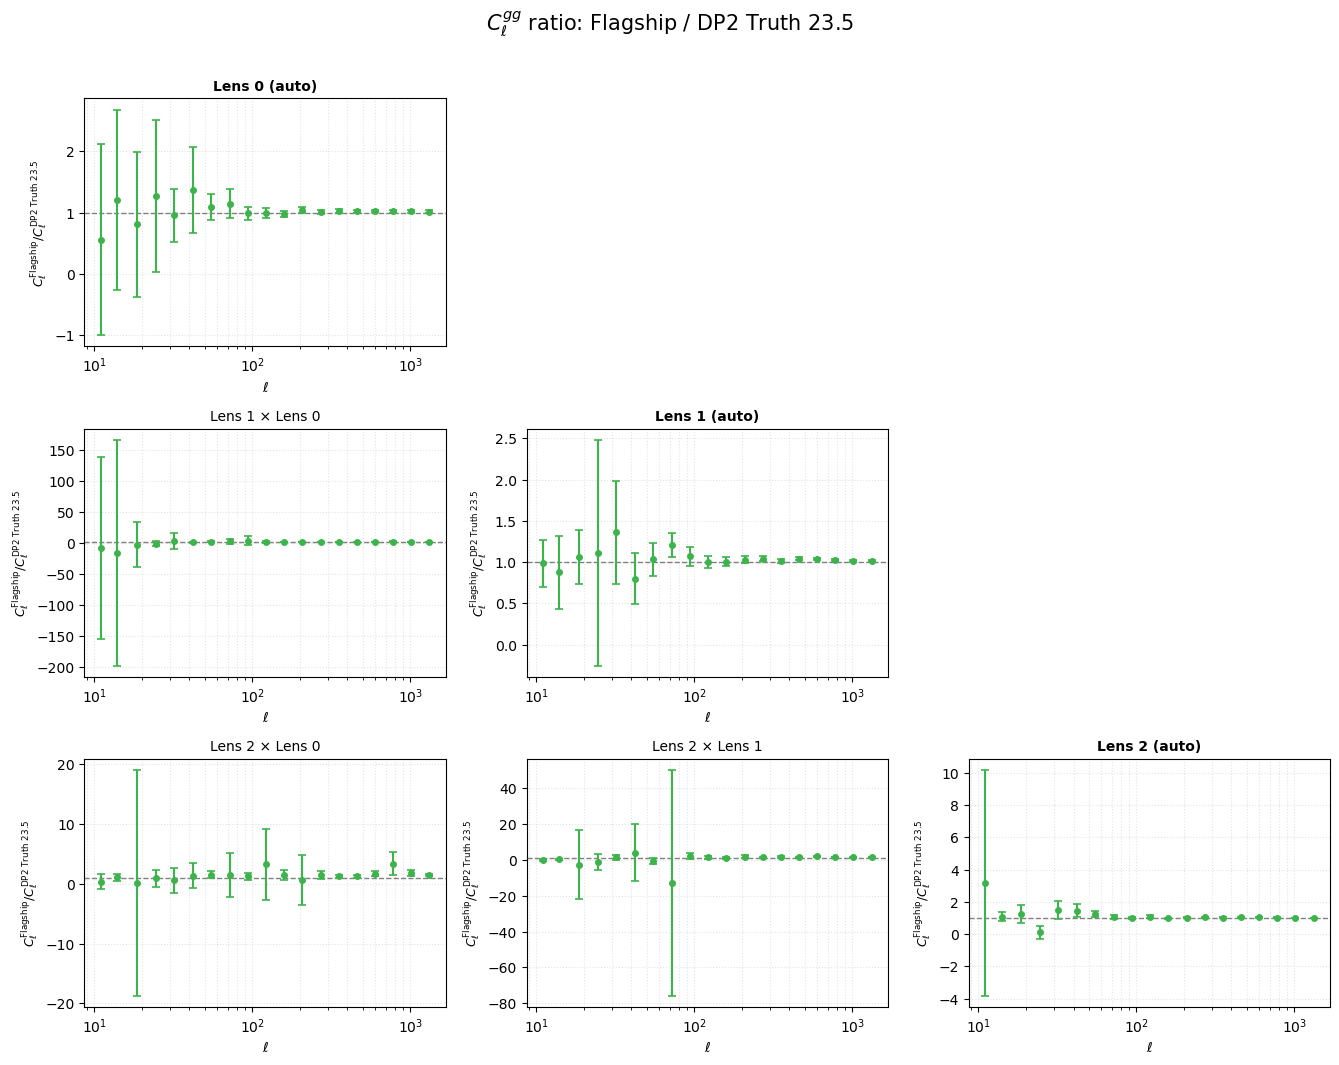

In [8]:
# ── ratio plot ────────────────────────────────────────────────────────────────
out = (
    f"{output_dir}/flagship_vs_truth_ratio.png"
    if output_dir else None
)
compare_cls_ratio(
    res_flagship, res_truth,
    "Flagship", "DP2 Truth 23.5",
    output_path=out,
)

f_sky  Flagship : 0.04352
f_sky  Truth    : 0.03656
CV ratio (sqrt(f_sky_truth/f_sky_flagship)): 0.9166


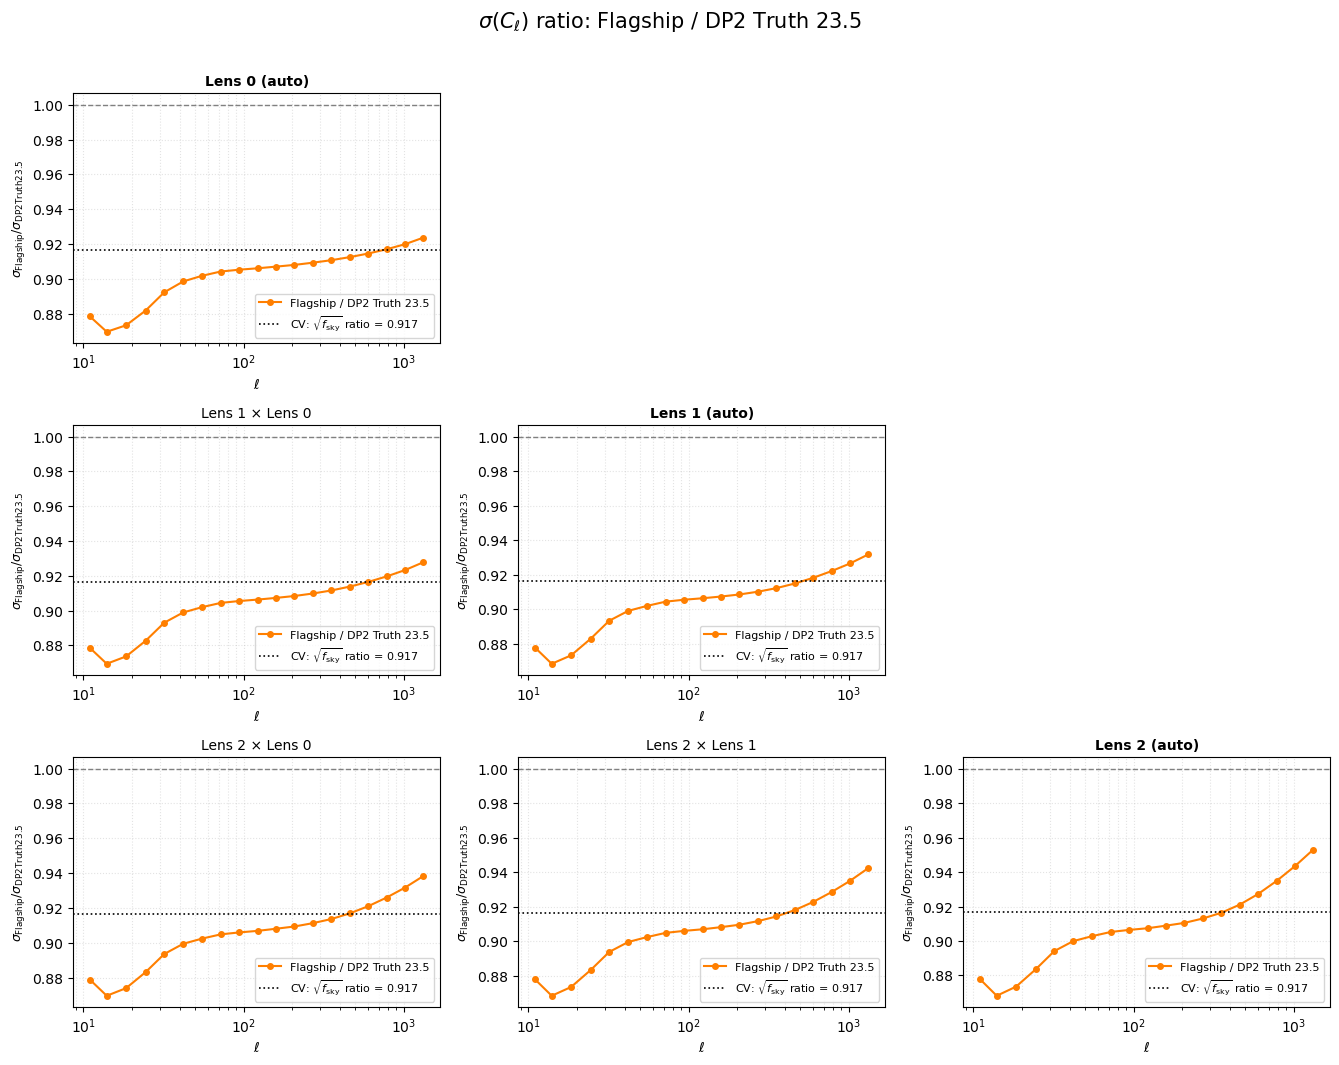

In [9]:
def compare_error_ratio(
    res_a,
    res_b,
    label_a,
    label_b,
    data_type="galaxy_density_cl",
    f_sky_a=None,
    f_sky_b=None,
    output_path=None,
):
    """Plot err_a / err_b for each bin pair.

    Shows which run has smaller statistical errors as a function of scale.
    A ratio < 1 means run A has smaller errors.
    If f_sky_a and f_sky_b are given, also draws the cosmic-variance reference
    line sqrt(f_sky_b / f_sky_a) — the expected ratio for CV-limited errors.
    """
    entries_a = res_a.get(data_type, [])
    entries_b = res_b.get(data_type, [])
    if not entries_a or not entries_b:
        print(f"No data for type '{data_type}'")
        return

    all_tracers = sorted(
        set(t for t1, t2, *_ in entries_a for t in (t1, t2)),
        key=lambda t: (t.rsplit("_", 1)[0], parse_bin_index(t)),
    )
    nbin = len(all_tracers)
    tidx = {t: i for i, t in enumerate(all_tracers)}

    lut_a = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_a}
    lut_b = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_b}

    cv_ratio = (
        float(np.sqrt(f_sky_b / f_sky_a))
        if (f_sky_a is not None and f_sky_b is not None)
        else None
    )

    fig, axes = plt.subplots(
        nbin, nbin,
        figsize=(4.5 * nbin, 3.5 * nbin),
        squeeze=False,
    )
    fig.suptitle(
        f"$\\sigma(C_\\ell)$ ratio: {label_a} / {label_b}",
        fontsize=15, y=1.01,
    )

    for r in range(nbin):
        for c in range(nbin):
            axes[r][c].set_visible(False)

    for t1, t2, *_ in entries_a:
        key = (t1, t2)
        if key not in lut_b:
            continue

        ell_a, _, err_a = lut_a[key]
        ell_b, _, err_b = lut_b[key]

        i = tidx[t1]
        j = tidx[t2]
        if i < j:
            i, j = j, i

        ax = axes[i][j]
        ax.set_visible(True)

        if not np.array_equal(ell_a, ell_b):
            err_b_interp = np.interp(ell_a, ell_b, err_b)
        else:
            err_b_interp = err_b

        with np.errstate(invalid="ignore", divide="ignore"):
            ratio = np.where(err_b_interp > 0, err_a / err_b_interp, np.nan)

        ax.axhline(1.0, color="grey", lw=1.0, ls="--")
        ax.plot(ell_a, ratio, "o-", ms=4, lw=1.5, color="#FF7F00",
                label=f"{label_a} / {label_b}")
        if cv_ratio is not None:
            ax.axhline(
                cv_ratio, color="black", lw=1.2, ls=":",
                label=f"CV: $\\sqrt{{f_{{\\rm sky}}}}$ ratio = {cv_ratio:.3f}",
            )
        ax.legend(fontsize=8, framealpha=0.8)

        ax.set_xscale("log")
        ax.grid(True, which="both", ls=":", alpha=0.35)

        title = (
            f"{bin_label(t1)} (auto)"
            if t1 == t2
            else f"{bin_label(t1)} \u00d7 {bin_label(t2)}"
        )
        ax.set_title(title, fontsize=10, fontweight="bold" if t1 == t2 else "normal")
        ax.set_xlabel(r"$\ell$", fontsize=10)
        ax.set_ylabel(
            f"$\\sigma_{{\\rm {label_a}}} / \\sigma_{{\\rm {label_b}}}$",
            fontsize=9,
        )

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()


# ── read f_sky from mask files ─────────────────────────────────────────────────
import h5py as _h5
import healpy as _hp

def _read_fsky(mask_path):
    with _h5.File(mask_path, "r") as f:
        attrs = {**dict(f["maps"].attrs), **dict(f["maps/mask"].attrs)}
        if "f_sky" in attrs:
            return float(attrs["f_sky"])
        pixel = f["maps/mask/pixel"][:]
        nside = int(attrs["nside"])
    return len(pixel) / _hp.nside2npix(nside)

_fsky_flagship = _read_fsky("data/outputs/flagship_lens/mask.hdf5")
_fsky_truth    = _read_fsky("/pscratch/sd/a/anicola/DP2/data/masks/dp2_23p5_combined_mask_nmin=500_nside=512.hdf5")
print(f"f_sky  Flagship : {_fsky_flagship:.5f}")
print(f"f_sky  Truth    : {_fsky_truth:.5f}")
print(f"CV ratio (sqrt(f_sky_truth/f_sky_flagship)): {np.sqrt(_fsky_truth/_fsky_flagship):.4f}")

# ── error ratio plot ───────────────────────────────────────────────────────────
out = (
    f"{output_dir}/flagship_vs_truth_error_ratio.png"
    if output_dir else None
)
compare_error_ratio(
    res_flagship, res_truth,
    "Flagship", "DP2 Truth 23.5",
    f_sky_a=_fsky_flagship,
    f_sky_b=_fsky_truth,
    output_path=out,
)


## Diagnostic plots

Sky footprint, redshift distribution, and magnitude distribution for each run.

In [10]:
# ── diagnostic data paths ────────────────────────────────────────────────────
import h5py

BASE = "data/outputs"
diag_runs = [
    dict(
        label="Flagship",
        mask=f"{BASE}/flagship_lens/mask.hdf5",
        photom=f"{BASE}/flagship_lens/photometry_catalog.hdf5",
        tomo=f"{BASE}/flagship_lens/lens_tomography_catalog_unweighted.hdf5",
    ),
    dict(
        label="DP2 Truth 23.5",
        mask="/pscratch/sd/a/anicola/DP2/data/masks/dp2_23p5_combined_mask_nmin=500_nside=512.hdf5",
        photom=f"{BASE}/dp2_23p5_nmin500_truth_combined_mask/photometry_catalog.hdf5",
        tomo=f"{BASE}/dp2_23p5_nmin500_truth_combined_mask/lens_tomography_catalog_unweighted.hdf5",
    ),
]

Flagship:
  Photometry catalog :  185,018,080
  Lens selected      :   39,819,300  (21.52%)
  Bin 0 (0.2–0.4)        :   13,889,044  (7.51%)
  Bin 1 (0.4–0.6)        :   15,417,442  (8.33%)
  Bin 2 (0.6–0.8)        :   10,512,814  (5.68%)

DP2 Truth 23.5:
  Photometry catalog :  185,018,080
  Lens selected      :   39,819,358  (21.52%)
  Bin 0 (0.2–0.4)        :   13,889,063  (7.51%)
  Bin 1 (0.4–0.6)        :   15,417,465  (8.33%)
  Bin 2 (0.6–0.8)        :   10,512,830  (5.68%)



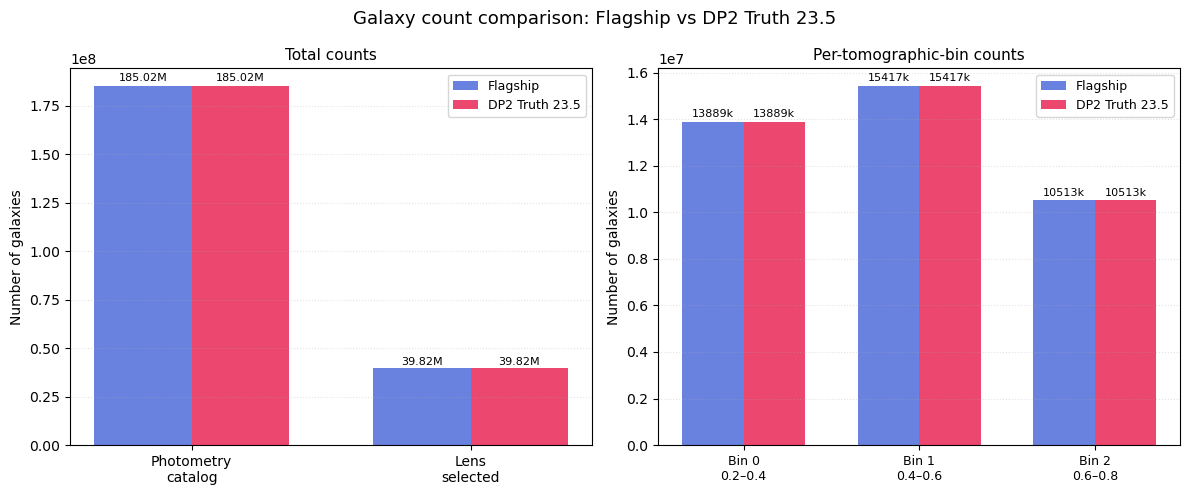

In [11]:
# ── galaxy count comparison ───────────────────────────────────────────────────
_COLORS = ["#4363D8", "#E6194B"]

count_data = []
for run in diag_runs:
    with h5py.File(run["photom"], "r") as f:
        attrs = dict(f["photometry"].attrs)
        n_photom = int(attrs.get("nobj", f["photometry/ra"].shape[0]))
    with h5py.File(run["tomo"], "r") as f:
        nbin       = int(f["tomography"].attrs["nbin"])
        zbin_edges = list(f["tomography"].attrs["zbin_edges"])
        tomo_bin   = f["tomography/bin"][:]
    n_selected = int((tomo_bin >= 0).sum())
    per_bin    = [int((tomo_bin == b).sum()) for b in range(nbin)]
    count_data.append(dict(
        label=run["label"], n_photom=n_photom,
        n_selected=n_selected, per_bin=per_bin,
    ))

# ── print table ───────────────────────────────────────────────────────────────
for d in count_data:
    print(f"{d['label']}:")
    print(f"  Photometry catalog : {d['n_photom']:>12,}")
    print(f"  Lens selected      : {d['n_selected']:>12,}  ({100*d['n_selected']/d['n_photom']:.2f}%)")
    for b, n in enumerate(d['per_bin']):
        zlo, zhi = zbin_edges[b], zbin_edges[b + 1]
        print(f"  Bin {b} ({zlo:.1f}\u2013{zhi:.1f})        : {n:>12,}  ({100*n/d['n_photom']:.2f}%)")
    print()

# ── bar charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
w = 0.35

# Left: photometry total vs lens-selected
ax = axes[0]
xlabels = ["Photometry\ncatalog", "Lens\nselected"]
x = np.arange(len(xlabels))
for ri, d in enumerate(count_data):
    vals = [d["n_photom"], d["n_selected"]]
    bars = ax.bar(x + (ri - 0.5) * w, vals, w,
                  color=_COLORS[ri % len(_COLORS)], alpha=0.8, label=d["label"])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{v/1e6:.2f}M", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("Number of galaxies", fontsize=10)
ax.set_title("Total counts", fontsize=11)
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, axis="y", ls=":", alpha=0.35)

# Right: per tomographic bin
ax = axes[1]
x = np.arange(nbin)
for ri, d in enumerate(count_data):
    bars = ax.bar(x + (ri - 0.5) * w, d["per_bin"], w,
                  color=_COLORS[ri % len(_COLORS)], alpha=0.8, label=d["label"])
    for bar, v in zip(bars, d["per_bin"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{v/1e3:.0f}k", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
bin_labels = [f"Bin {b}\n{zbin_edges[b]:.1f}\u2013{zbin_edges[b+1]:.1f}" for b in range(nbin)]
ax.set_xticklabels(bin_labels, fontsize=9)
ax.set_ylabel("Number of galaxies", fontsize=10)
ax.set_title("Per-tomographic-bin counts", fontsize=11)
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, axis="y", ls=":", alpha=0.35)

fig.suptitle("Galaxy count comparison: Flagship vs DP2 Truth 23.5", fontsize=13)
plt.tight_layout()
plt.show()


In [12]:
import healpy as hp


def read_txpipe_mask(mask_path, mask_name="mask", threshold=0.0):
    """Read a TXPipe mask HDF5 file and return a full HEALPix map (RING)."""
    with h5py.File(mask_path, "r") as f:
        mask_group = f[f"maps/{mask_name}"]
        pixel    = mask_group["pixel"][:]
        value    = mask_group["value"][:]
        metadata = {}
        for attrs in [dict(f["maps"].attrs), dict(mask_group.attrs)]:
            metadata.update(attrs)

    nside    = int(metadata["nside"])
    nest     = bool(metadata.get("nest", False))
    npix     = hp.nside2npix(nside)
    mask_map = np.full(npix, hp.UNSEEN, dtype=np.float64)
    mask_map[pixel] = value

    if threshold > 0.0:
        mask_map[(mask_map != hp.UNSEEN) & (mask_map <= threshold)] = hp.UNSEEN

    if nest:
        mask_map = hp.reorder(mask_map, n2r=True)

    n_valid   = int((mask_map != hp.UNSEEN).sum())
    area_deg2 = n_valid * hp.nside2pixarea(nside, degrees=True)
    f_sky     = n_valid / npix
    metadata.update(dict(n_valid_pixels=n_valid, area_deg2=area_deg2, f_sky_computed=f_sky))
    return mask_map, nside, metadata

/global/homes/a/anicola/.conda/envs/dp2_env/lib/python3.14/site-packages/healpy/visufunc.py:1630: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  ax.graticule(dpar=dpar, dmer=dmer, coord=coord, local=local, **kwds)


/tmp/ipykernel_1434632/4164033967.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


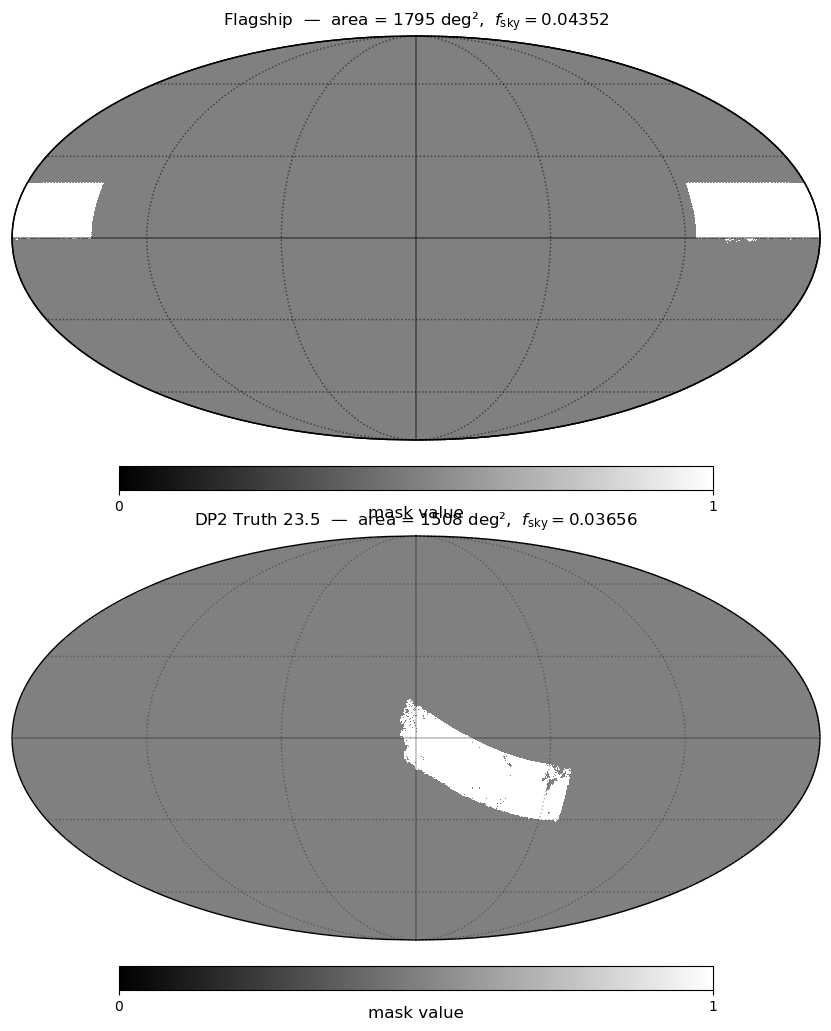

In [13]:
def plot_sky_coverage_comparison(runs, output_path=None):
    """Full-sky Mollweide view of each run\'s footprint, stacked vertically."""
    nruns = len(runs)
    fig = plt.figure(figsize=(12, 5 * nruns))

    for idx, run in enumerate(runs):
        mask_map, nside, meta = read_txpipe_mask(run["mask"])
        area   = meta["area_deg2"]
        f_sky  = meta["f_sky_computed"]
        title  = (f"{run['label']}  —  area = {area:.0f} deg²,  "
                  f"$f_{{\\rm sky}} = {f_sky:.5f}$")

        sub = idx * 100 + nruns * 100 + 1   # e.g. for 2 runs: 211, 212
        hp.mollview(
            mask_map,
            fig=fig.number,
            sub=(nruns, 1, idx + 1),
            title=title,
            cmap="binary_r",
            min=0, max=1,
            cbar=True,
            notext=False,
            unit="mask value",
        )
        hp.graticule(dpar=30, dmer=60, alpha=0.3, verbose=False)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()


plot_sky_coverage_comparison(diag_runs)

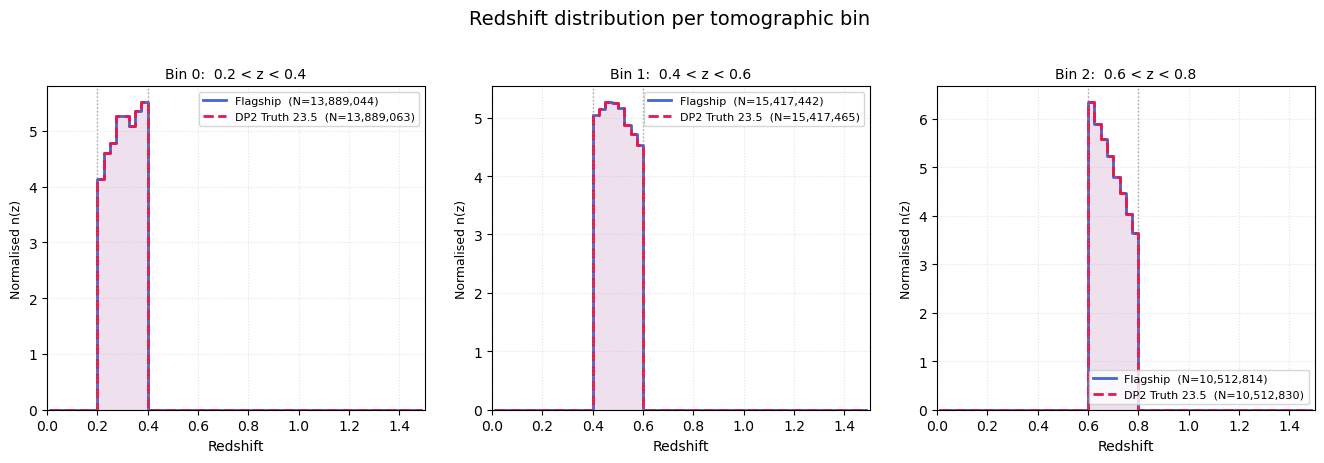

In [14]:
RUN_COLORS = ["#4363D8", "#E6194B"]
RUN_LS     = ["-",      "--"]


def compare_redshift_distributions(runs, z_min=0.0, z_max=1.5, n_z_bins=60, output_path=None):
    """Overlaid normalised n(z) per tomographic bin for multiple runs."""
    # Determine nbin from the first run
    with h5py.File(runs[0]["tomo"], "r") as f:
        nbin       = int(f["tomography"].attrs["nbin"])
        zbin_edges = f["tomography"].attrs["zbin_edges"]

    z_edges = np.linspace(z_min, z_max, n_z_bins + 1)
    z_mid   = 0.5 * (z_edges[:-1] + z_edges[1:])

    fig, axes = plt.subplots(1, nbin, figsize=(4.5 * nbin, 4.5), sharey=False)
    if nbin == 1:
        axes = [axes]
    fig.suptitle("Redshift distribution per tomographic bin", fontsize=14, y=1.02)

    for run_idx, run in enumerate(runs):
        color = RUN_COLORS[run_idx % len(RUN_COLORS)]
        ls    = RUN_LS[run_idx % len(RUN_LS)]

        with h5py.File(run["photom"], "r") as f:
            z_all = f["photometry/redshift_true"][:]
        with h5py.File(run["tomo"], "r") as f:
            tomo_bin = f["tomography/bin"][:]

        for b in range(nbin):
            ax  = axes[b]
            sel = tomo_bin == b
            if sel.sum() == 0:
                continue

            h, _ = np.histogram(z_all[sel], bins=z_edges)
            norm = np.trapezoid(h, z_mid)
            nz   = h / norm if norm > 0 else h

            ax.step(z_mid, nz, where="mid",
                    color=color, lw=2.0, ls=ls,
                    label=f"{run['label']}  (N={sel.sum():,})")
            ax.fill_between(z_mid, nz, step="mid",
                            color=color, alpha=0.08)

    # Decorations (bin edges, labels)
    for b in range(nbin):
        ax  = axes[b]
        zlo = zbin_edges[b]
        zhi = zbin_edges[b + 1]
        ax.axvline(zlo, color="grey", ls=":", lw=1.0, alpha=0.7)
        ax.axvline(zhi, color="grey", ls=":", lw=1.0, alpha=0.7)
        ax.set_title(f"Bin {b}:  {zlo:.1f} < z < {zhi:.1f}", fontsize=10)
        ax.set_xlabel("Redshift", fontsize=10)
        ax.set_ylabel("Normalised n(z)", fontsize=9)
        ax.set_xlim(z_min, z_max)
        ax.set_ylim(bottom=0)
        ax.grid(True, ls=":", alpha=0.35)
        ax.legend(fontsize=8, framealpha=0.8)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()


compare_redshift_distributions(diag_runs)

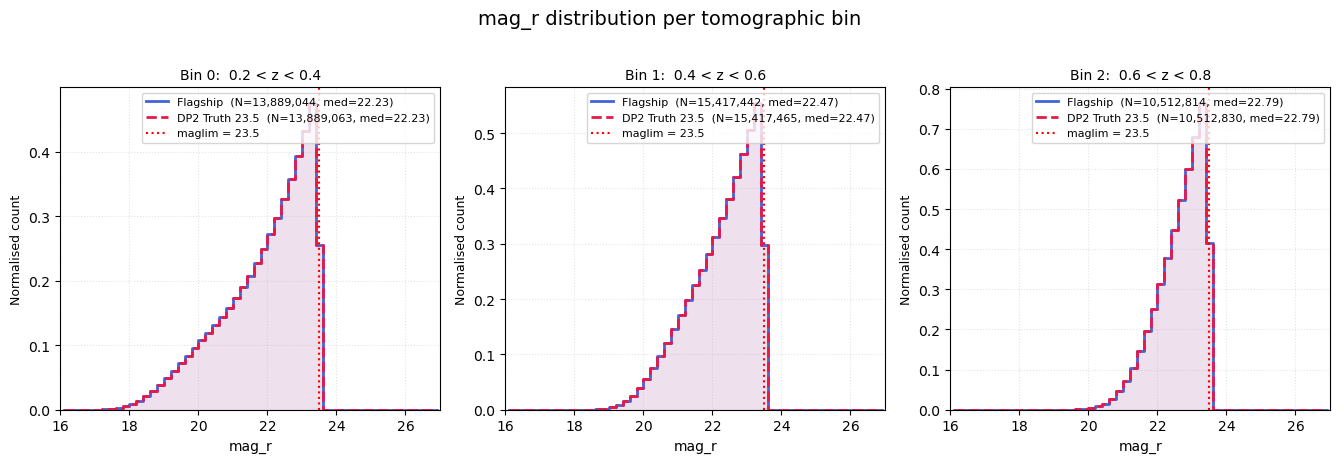

In [15]:
def compare_mag_distributions(runs, band="r", maglim=23.5,
                             mag_min=16.0, mag_max=27.0, n_bins=55, output_path=None):
    """Overlaid normalised magnitude histograms per tomographic bin for multiple runs."""
    with h5py.File(runs[0]["tomo"], "r") as f:
        nbin       = int(f["tomography"].attrs["nbin"])
        zbin_edges = f["tomography"].attrs["zbin_edges"]

    mag_edges = np.linspace(mag_min, mag_max, n_bins + 1)
    mag_mid   = 0.5 * (mag_edges[:-1] + mag_edges[1:])

    fig, axes = plt.subplots(1, nbin, figsize=(4.5 * nbin, 4.5), sharey=False)
    if nbin == 1:
        axes = [axes]
    fig.suptitle(f"mag_{band} distribution per tomographic bin", fontsize=14, y=1.02)

    for run_idx, run in enumerate(runs):
        color = RUN_COLORS[run_idx % len(RUN_COLORS)]
        ls    = RUN_LS[run_idx % len(RUN_LS)]

        with h5py.File(run["photom"], "r") as f:
            mag_all = f[f"photometry/mag_{band}"][:]
        with h5py.File(run["tomo"], "r") as f:
            tomo_bin = f["tomography/bin"][:]

        for b in range(nbin):
            ax  = axes[b]
            sel = tomo_bin == b
            if sel.sum() == 0:
                continue

            h, _ = np.histogram(mag_all[sel], bins=mag_edges)
            norm  = np.trapezoid(h, mag_mid)
            h_n   = h / norm if norm > 0 else h
            med   = np.median(mag_all[sel])

            ax.step(mag_mid, h_n, where="mid",
                    color=color, lw=2.0, ls=ls,
                    label=f"{run['label']}  (N={sel.sum():,}, med={med:.2f})")
            ax.fill_between(mag_mid, h_n, step="mid",
                            color=color, alpha=0.08)

    for b in range(nbin):
        ax  = axes[b]
        zlo = zbin_edges[b]
        zhi = zbin_edges[b + 1]
        ax.axvline(maglim, color="red", ls=":", lw=1.5,
                   label=f"maglim = {maglim}")
        ax.set_title(f"Bin {b}:  {zlo:.1f} < z < {zhi:.1f}", fontsize=10)
        ax.set_xlabel(f"mag_{band}", fontsize=10)
        ax.set_ylabel("Normalised count", fontsize=9)
        ax.set_xlim(mag_min, mag_max)
        ax.set_ylim(bottom=0)
        ax.grid(True, ls=":", alpha=0.35)
        ax.legend(fontsize=8, framealpha=0.8)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()


compare_mag_distributions(diag_runs, band="r", maglim=23.5)

## Raw Flagship parquet: full-catalog distributions

Reads the flagship parquet files directly (no TXPipe, no cuts) to show the
total galaxy count, raw redshift distribution, and magnitude distributions
for all six LSST bands.

Total galaxies (both tiles): 901,292
After mag_r <= 23.5:  31,894  (3.5%)


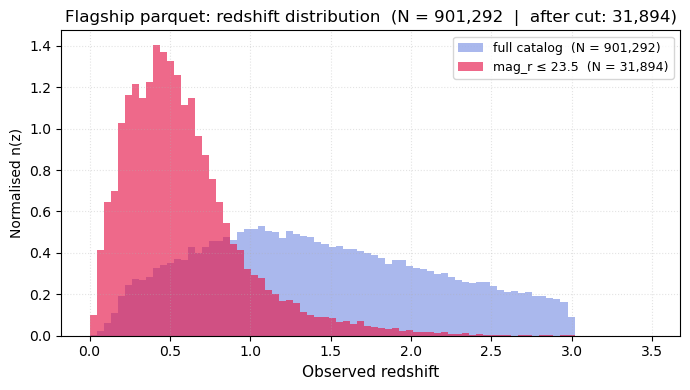

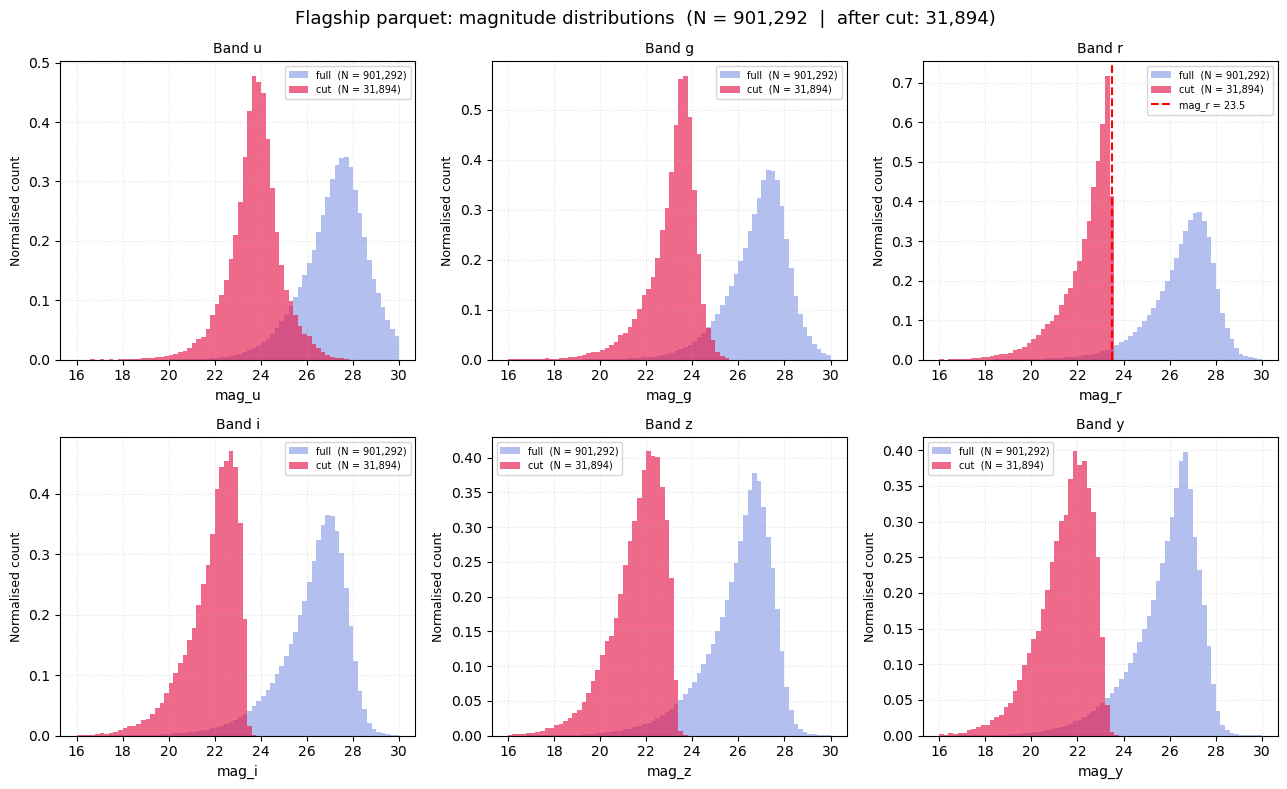

In [39]:
import pyarrow.parquet as pq
import pandas as pd

FLAGSHIP_PQ_PATHS = [
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/"
    "flagship-ramin-145-ramax-160-decmin-40-decmax-50-small.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/"
    "flagship-ramin-200-ramax-210-decmin-20-decmax-30-small.pq",
]

BANDS     = list("ugrizy")
FLUX_COLS = [f"lsst_{b}_el_model3_ext" for b in BANDS]
Z_COL     = "observed_redshift_gal"
READ_COLS = FLUX_COLS + [Z_COL]

# ── magnitude cut (set maglim=None to disable) ─────────────────────────────
maglim_band = "r"
maglim      = 23.5      # set to None to show full catalog only

# ── load both files ────────────────────────────────────────────────────────
frames = [pq.read_table(p, columns=READ_COLS).to_pandas() for p in FLAGSHIP_PQ_PATHS]
df = pd.concat(frames, ignore_index=True)
n_gal = len(df)
print(f"Total galaxies (both tiles): {n_gal:,}")

# ── flux → AB magnitude ────────────────────────────────────────────────────
def _flux_to_ab_mag(flux):
    mag = np.full(len(flux), 99.0)
    good = flux > 0
    mag[good] = -2.5 * np.log10(flux[good]) - 48.6
    return mag

for col, band in zip(FLUX_COLS, BANDS):
    df[f"mag_{band}"] = _flux_to_ab_mag(df[col].to_numpy())

# ── optional magnitude cut ─────────────────────────────────────────────────
if maglim is not None:
    sel_cut = df[f"mag_{maglim_band}"].to_numpy() <= maglim
    n_cut   = int(sel_cut.sum())
    print(f"After mag_{maglim_band} <= {maglim}:  {n_cut:,}  ({100 * n_cut / n_gal:.1f}%)")
else:
    sel_cut = None
    n_cut   = None

# ── redshift distribution ──────────────────────────────────────────────────
z_all = df[Z_COL].to_numpy()
cut_label = (
    f"mag_{maglim_band} \u2264 {maglim}  (N = {n_cut:,})"
    if sel_cut is not None else None
)
title_n = (
    f"N = {n_gal:,}" if sel_cut is None
    else f"N = {n_gal:,}  |  after cut: {n_cut:,}"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(z_all, bins=80, range=(0.0, 3.5),
        color="#4363D8", alpha=0.45, histtype="stepfilled", density=True,
        label=f"full catalog  (N = {n_gal:,})")
if sel_cut is not None:
    ax.hist(z_all[sel_cut], bins=80, range=(0.0, 3.5),
            color="#E6194B", alpha=0.65, histtype="stepfilled", density=True,
            label=cut_label)
    ax.legend(fontsize=9, framealpha=0.8)
ax.set_xlabel("Observed redshift", fontsize=11)
ax.set_ylabel("Normalised n(z)", fontsize=10)
ax.set_title(f"Flagship parquet: redshift distribution  ({title_n})", fontsize=12)
ax.grid(True, ls=":", alpha=0.35)
plt.tight_layout()
plt.show()

# ── magnitude distributions ────────────────────────────────────────────────
cut_suffix = (
    f"  |  after cut: {n_cut:,}" if sel_cut is not None else ""
)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle(
    f"Flagship parquet: magnitude distributions  (N = {n_gal:,}{cut_suffix})",
    fontsize=13,
)
for ax, band in zip(axes.flat, BANDS):
    mag_all = df[f"mag_{band}"].to_numpy()
    finite  = mag_all[(mag_all < 99) & np.isfinite(mag_all)]
    ax.hist(finite, bins=70, range=(16, 30),
            color="#4363D8", alpha=0.40, histtype="stepfilled", density=True,
            label=f"full  (N = {len(finite):,})")
    if sel_cut is not None:
        mag_cut = mag_all[sel_cut]
        finite_cut = mag_cut[(mag_cut < 99) & np.isfinite(mag_cut)]
        ax.hist(finite_cut, bins=70, range=(16, 30),
                color="#E6194B", alpha=0.65, histtype="stepfilled", density=True,
                label=f"cut  (N = {len(finite_cut):,})")
        if band == maglim_band:
            ax.axvline(maglim, color="red", ls="--", lw=1.5,
                       label=f"mag_{maglim_band} = {maglim}")
        ax.legend(fontsize=7, framealpha=0.8)
    ax.set_xlabel(f"mag_{band}", fontsize=10)
    ax.set_ylabel("Normalised count", fontsize=9)
    ax.set_title(f"Band {band}", fontsize=10)
    ax.grid(True, ls=":", alpha=0.35)
plt.tight_layout()
plt.show()
